# Model training of **Resturant Revenue** Dataset using **Logistic regression**

In [1]:
#importing necessary libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Restaurant_revenue (1).csv to Restaurant_revenue (1) (2).csv


In [3]:
df = pd.read_csv("Restaurant_revenue (1).csv")

In [4]:
df

,Number_of_Customers,Menu_Price,Marketing_Spend,Cuisine_Type,Average_Customer_Spending,Promotions,Reviews,Monthly_Revenue
0,61,43.117635,12.663793,Japanese,36.236133,0,45,350.912040
1,24,40.020077,4.577892,Italian,17.952562,0,36,221.319091
2,81,41.981485,4.652911,Japanese,22.600420,1,91,326.529763
3,70,43.005307,4.416053,Italian,18.984098,1,59,348.190573
4,30,17.456199,3.475052,Italian,12.766143,1,30,185.009121
...,...,...,...,...,...,...,...,...
995,73,41.307842,12.122931,Japanese,19.033585,1,40,249.312034
996,31,20.615496,5.822885,Mexican,17.040990,0,57,110.228767
997,69,17.110656,4.141898,Japanese,44.649315,0,55,312.212552
998,73,37.664722,3.046556,Japanese,27.767358,0,23,272.482204


**Data Exploration:** Exploring the dataset to understand its structure, data types, statistical summary, and identify any missing values.

In [5]:
df.head()

,Number_of_Customers,Menu_Price,Marketing_Spend,Cuisine_Type,Average_Customer_Spending,Promotions,Reviews,Monthly_Revenue
0,61,43.117635,12.663793,Japanese,36.236133,0,45,350.912040
1,24,40.020077,4.577892,Italian,17.952562,0,36,221.319091
2,81,41.981485,4.652911,Japanese,22.600420,1,91,326.529763
3,70,43.005307,4.416053,Italian,18.984098,1,59,348.190573
4,30,17.456199,3.475052,Italian,12.766143,1,30,185.009121


In [6]:
df.tail()

,Number_of_Customers,Menu_Price,Marketing_Spend,Cuisine_Type,Average_Customer_Spending,Promotions,Reviews,Monthly_Revenue
995,73,41.307842,12.122931,Japanese,19.033585,1,40,249.312034
996,31,20.615496,5.822885,Mexican,17.040990,0,57,110.228767
997,69,17.110656,4.141898,Japanese,44.649315,0,55,312.212552
998,73,37.664722,3.046556,Japanese,27.767358,0,23,272.482204
999,81,34.722067,17.989104,Italian,15.482112,1,72,379.973072


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Number_of_Customers        1000 non-null   int64  
 1   Menu_Price                 1000 non-null   float64
 2   Marketing_Spend            1000 non-null   float64
 3   Cuisine_Type               1000 non-null   object 
 4   Average_Customer_Spending  1000 non-null   float64
 5   Promotions                 1000 non-null   int64  
 6   Reviews                    1000 non-null   int64  
 7   Monthly_Revenue            1000 non-null   float64
dtypes: float64(4), int64(3), object(1)
memory usage: 62.6+ KB


In [8]:
df.describe()

,Number_of_Customers,Menu_Price,Marketing_Spend,Average_Customer_Spending,Promotions,Reviews,Monthly_Revenue
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,53.271000,30.219120,9.958726,29.477085,0.497000,49.837000,268.724172
std,26.364914,11.278760,5.845586,11.471686,0.500241,29.226334,103.982950
min,10.000000,10.009501,0.003768,10.037177,0.000000,0.000000,-28.977809
25%,30.000000,20.396828,4.690724,19.603041,0.000000,24.000000,197.103642
50%,54.000000,30.860614,10.092047,29.251365,0.000000,50.000000,270.213964
75%,74.000000,39.843868,14.992436,39.553220,1.000000,76.000000,343.395793
max,99.000000,49.974140,19.994276,49.900725,1.000000,99.000000,563.381332


In [9]:
df.isnull().sum()

,0
Number_of_Customers,0
Menu_Price,0
Marketing_Spend,0
Cuisine_Type,0
Average_Customer_Spending,0
Promotions,0
Reviews,0
Monthly_Revenue,0


**Data Preprocessing:** The dataset is modified by converting the target variable into binary classes and encoding categorical data to prepare it for Logistic Regression.

In [10]:
# Create binary target using median revenue
median = df["Monthly_Revenue"].median()

df["Revenue_Category"] = (df["Monthly_Revenue"] >= median).astype(int)

In [11]:
# Encode cuisine names into numbers
le = LabelEncoder()

df["Cuisine_Type"] = le.fit_transform(df["Cuisine_Type"])
le = LabelEncoder()

df["Cuisine_Type"] = le.fit_transform(df["Cuisine_Type"])

In [12]:
#check updates dataset
df.head()

,Number_of_Customers,Menu_Price,Marketing_Spend,Cuisine_Type,Average_Customer_Spending,Promotions,Reviews,Monthly_Revenue,Revenue_Category
0,61,43.117635,12.663793,2,36.236133,0,45,350.912040,1
1,24,40.020077,4.577892,1,17.952562,0,36,221.319091,0
2,81,41.981485,4.652911,2,22.600420,1,91,326.529763,1
3,70,43.005307,4.416053,1,18.984098,1,59,348.190573,1
4,30,17.456199,3.475052,1,12.766143,1,30,185.009121,0


In [13]:
#importing seaborn library
import seaborn as sns

In [14]:
# Calculate correlation between features
corr = df.corr(numeric_only=True)

corr

,Number_of_Customers,Menu_Price,Marketing_Spend,Cuisine_Type,Average_Customer_Spending,Promotions,Reviews,Monthly_Revenue,Revenue_Category
Number_of_Customers,1.000000,0.033470,-0.007024,-0.002909,-0.013898,0.058693,-0.010140,0.745239,0.634456
Menu_Price,0.033470,1.000000,0.016319,0.009616,0.020808,0.022068,0.003792,0.259579,0.208109
Marketing_Spend,-0.007024,0.016319,1.000000,-0.037691,-0.058586,-0.041838,-0.031470,0.269929,0.205697
Cuisine_Type,-0.002909,0.009616,-0.037691,1.000000,-0.033552,-0.002639,-0.033232,0.007496,0.007121
Average_Customer_Spending,-0.013898,0.020808,-0.058586,-0.033552,1.000000,0.006620,0.054163,-0.035665,-0.057800
Promotions,0.058693,0.022068,-0.041838,-0.002639,0.006620,1.000000,-0.021635,0.014869,0.006000
Reviews,-0.010140,0.003792,-0.031470,-0.033232,0.054163,-0.021635,1.000000,-0.024946,-0.019889
Monthly_Revenue,0.745239,0.259579,0.269929,0.007496,-0.035665,0.014869,-0.024946,1.000000,0.801656
Revenue_Category,0.634456,0.208109,0.205697,0.007121,-0.057800,0.006000,-0.019889,0.801656,1.000000


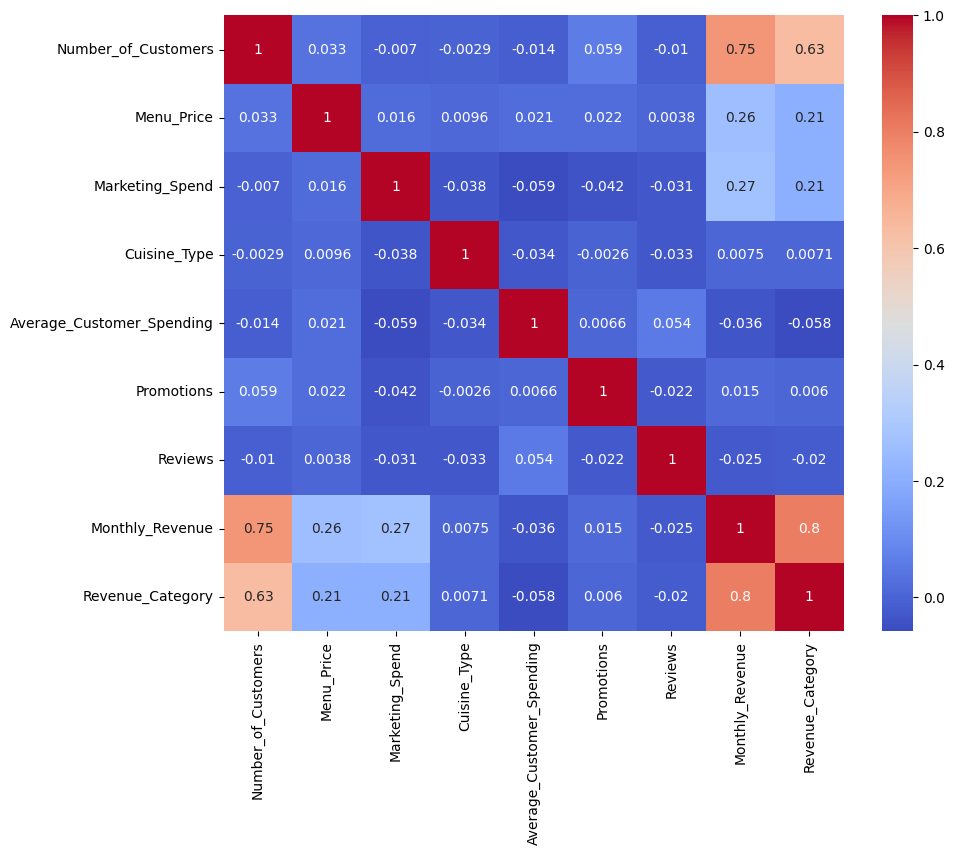

In [15]:
# Visualize the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

**Dividing the Data into X and Y:** Separating the input features (X) and target variable (Y) for model training.

In [16]:
# Divide the data into X and y
X = df.drop(["Monthly_Revenue", "Revenue_Category"], axis=1)
y = df["Revenue_Category"]

In [17]:
#display features
X.head()

,Number_of_Customers,Menu_Price,Marketing_Spend,Cuisine_Type,Average_Customer_Spending,Promotions,Reviews
0,61,43.117635,12.663793,2,36.236133,0,45
1,24,40.020077,4.577892,1,17.952562,0,36
2,81,41.981485,4.652911,2,22.600420,1,91
3,70,43.005307,4.416053,1,18.984098,1,59
4,30,17.456199,3.475052,1,12.766143,1,30


In [18]:
#display target
y.head()

,Revenue_Category
0,1
1,0
2,1
3,1
4,0


In [19]:
# Split the dataset into training and testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [20]:
X_train

,Number_of_Customers,Menu_Price,Marketing_Spend,Cuisine_Type,Average_Customer_Spending,Promotions,Reviews
29,51,45.145165,1.292334,1,15.143859,0,96
535,22,27.329870,6.816314,0,30.723087,0,10
695,34,33.386828,6.264125,1,22.072375,1,77
557,92,47.649500,18.147603,1,33.307446,0,21
836,82,22.082420,2.903930,1,45.617638,1,70
...,...,...,...,...,...,...,...
106,97,19.929058,18.405944,1,12.178642,0,16
270,57,48.483951,0.268053,3,39.563657,0,27
860,11,37.033650,12.741817,2,47.505591,0,96
435,57,42.797877,11.544995,0,33.974920,1,47


In [21]:
X_test

,Number_of_Customers,Menu_Price,Marketing_Spend,Cuisine_Type,Average_Customer_Spending,Promotions,Reviews
521,45,46.473441,4.404506,2,32.219891,0,19
737,54,16.371498,15.850428,3,21.667738,1,10
740,71,44.657547,2.959683,2,21.569756,0,46
660,96,33.948559,7.401047,2,23.834354,0,5
411,15,45.316251,19.469148,2,39.011483,1,44
...,...,...,...,...,...,...,...
408,69,45.779197,16.459169,1,12.891078,1,81
332,55,29.191253,14.985674,2,18.491426,0,33
208,96,37.648874,11.987379,2,18.860691,1,36
613,83,18.143131,10.991673,2,38.763025,1,95


In [22]:
y_train

,Revenue_Category
29,0
535,0
695,0
557,1
836,1
...,...
106,1
270,1
860,0
435,1


In [23]:
y_test

,Revenue_Category
521,1
737,0
740,1
660,1
411,1
...,...
408,1
332,1
208,1
613,1


**Creating and Training the Model:** Initializing the Logistic Regression model and training it using the training dataset.

In [24]:
model = LogisticRegression()

In [25]:
model.fit(X_train,y_train)

LogisticRegression()

In [26]:
#predict the test data
y_pred = model.predict(X_test)

In [27]:
y_pred

array([0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1,
       1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1,
       1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
       1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0,
       1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0,
       0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       1, 1])

**Model Evaluation:** Evaluating the model's performance using accuracy score, confusion matrix, and classification report.

In [28]:
model.score(X_train,y_train)

0.8225

In [29]:
model.score(X_test,y_test)

0.815

In [30]:
# Calculate the accuracy
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

Accuracy: 0.815


In [31]:
# Display the confusion matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[91 21]
 [16 72]]


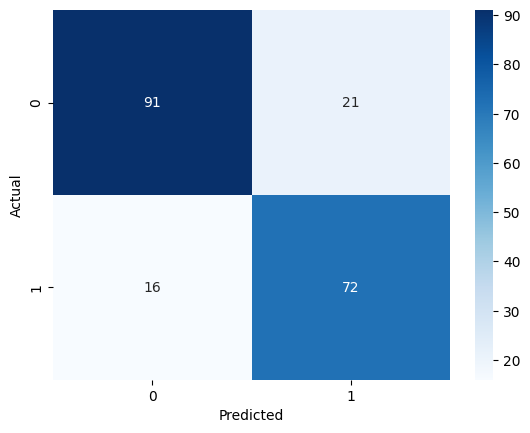

In [32]:
# Visualize the confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**Conclusion:** The Logistic Regression model was successfully trained to classify restaurants into high and low revenue categories based on the given features. The model's performance was evaluated using accuracy, confusion matrix, and classification report.